# WNAR-SW: Weighted Negative Association Rule Mining with Regularity
## Experimental Comparison Notebook

**Authors:** Djouhara Deghbar, Nesrine Dekkiche  
**Department of Computer Science, USTHB**

---

This notebook implements and compares four algorithms on a medical side-effect dataset:

| # | Algorithm | Reference |
|---|-----------|----------|
| 1 | Standard Apriori | Agrawal & Srikant (1994) |
| 2 | Frequent+Regular Negative Association Mining | Jammalamadaka & Budaraju (2025) |
| 3 | Weighted Streaming Association Mining (MWAR-SW) | Ouyang & Huang (2015) |
| 4 | **WNAR-SW** (proposed) | This work |

Each algorithm is evaluated on the same sliding window of drug side-effect profiles.

---
## Section 1 — Imports

In [1]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict
import time
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


---
## Section 2 — Data Loading and Transaction Extraction

In [2]:
df = pd.read_csv('medicine_dataset.csv')

print(f"Dataset shape : {df.shape}")
print(f"Total drugs   : {df.shape[0]}")

# Side effects are stored as string values in columns sideEffect0 ... sideEffect41
side_effect_cols = [col for col in df.columns if col.startswith('sideEffect')]
print(f"Side-effect columns found : {len(side_effect_cols)}")


def extract_transactions(df, side_effect_cols, min_length=2):
    """
    Build one transaction per drug row.
    Each transaction is the list of non-null side-effect strings for that drug.
    Only rows with at least min_length distinct side effects are kept.
    """
    transactions = []
    for _, row in df[side_effect_cols].iterrows():
        effects = list(dict.fromkeys([
            str(v).strip()
            for v in row
            if pd.notna(v) and str(v).strip() != ''
        ]))
        if len(effects) >= min_length:
            transactions.append(effects)
    return transactions


transactions = extract_transactions(df, side_effect_cols)

sizes = [len(t) for t in transactions]
print(f"\nTransactions extracted : {len(transactions)}")
print(f"Side-effects per drug  : min={min(sizes)}, max={max(sizes)}, mean={np.mean(sizes):.1f}")
print(f"\nSample (first drug)    : {transactions[0]}")

Dataset shape : (248218, 58)
Total drugs   : 248218
Side-effect columns found : 42

Transactions extracted : 238416
Side-effects per drug  : min=2, max=42, mean=6.7

Sample (first drug)    : ['Vomiting', 'Nausea', 'Diarrhea']


---
## Section 3 — Clinical Severity Weights

Weights follow the scale proposed in the paper:  
`omega(x) in (0, 1]`, where 1.0 = life-threatening, 0.1 = trivial.

Items not in the predefined table receive a neutral default of **0.40** (moderate).

In [3]:
SEVERITY_TABLE = {
    # ---- Critical (0.90 – 1.00) ----------------------------------------
    'SEIZURES': 1.00, 'HEART_ATTACK': 1.00, 'STROKE': 1.00,
    'CARDIAC_ARREST': 1.00, 'LIVER_FAILURE': 0.95, 'KIDNEY_FAILURE': 0.95,
    'RESPIRATORY_FAILURE': 0.95, 'ANAPHYLAXIS': 0.95,
    'SEVERE_ALLERGIC_REACTION': 0.92, 'SUICIDAL_THOUGHTS': 0.90,
    'BLOOD_CLOTS': 0.90,

    # ---- Severe (0.65 – 0.89) ------------------------------------------
    'BLEEDING': 0.85, 'INTERNAL_BLEEDING': 0.88, 'CHEST_PAIN': 0.85,
    'DIFFICULTY_BREATHING': 0.85, 'BREATHLESSNESS': 0.85,
    'HALLUCINATIONS': 0.80, 'ALLERGIC_REACTION': 0.80,
    'IRREGULAR_HEARTBEAT': 0.78, 'INCREASED_LIVER_ENZYMES': 0.78,
    'MEMORY_LOSS': 0.78, 'CONFUSION': 0.75,
    'ORTHOSTATIC_HYPOTENSION_(SUDDEN_LOWERING_OF_BLOOD_PRESSURE_ON_STANDING)': 0.75,
    'ORTHOSTATIC_HYPOTENSION': 0.75, 'HIGH_BLOOD_PRESSURE': 0.75,
    'LOW_BLOOD_PRESSURE': 0.75, 'TACHYCARDIA': 0.72,
    'PALPITATIONS': 0.72, 'INCREASED_HEART_RATE': 0.72,
    'ERECTILE_DYSFUNCTION': 0.70, 'VISION_PROBLEMS': 0.70,
    'BLURRED_VISION': 0.68, 'SLOW_HEART_RATE': 0.65,
    'INCREASED_CREATININE_LEVEL_IN_BLOOD': 0.65, 'DEPRESSION': 0.65,

    # ---- Moderate (0.40 – 0.64) ----------------------------------------
    'VOMITING': 0.60, 'BREAST_ENLARGEMENT_IN_MALE': 0.60, 'SWELLING': 0.60,
    'BALANCE_DISORDER_(LOSS_OF_BALANCE)': 0.60, 'EDEMA': 0.58,
    'FEVER': 0.58, 'ANXIETY': 0.55, 'DIARRHEA': 0.55,
    'STOMACH_PAIN': 0.55, 'ABDOMINAL_PAIN': 0.55,
    'STOMACH_PAIN/EPIGASTRIC_PAIN': 0.55, 'COLD_EXTREMITIES': 0.55,
    'UPPER_RESPIRATORY_TRACT_INFECTION': 0.50, 'FLU-LIKE_SYMPTOMS': 0.50,
    'RASH': 0.50, 'GASTROINTESTINAL_DISTURBANCE': 0.50,
    'HIVES': 0.52, 'SKIN_RASH': 0.50, 'IMPOTENCE': 0.55,
    'ANKLE_SWELLING': 0.55, 'EDEMA_(SWELLING)': 0.58,
    'UNUSUAL_PRODUCTION_OF_BREAST_MILK_IN_WOMEN_AND_MEN': 0.55,
    'SEDATION': 0.55, 'WEAKNESS': 0.45, 'TREMORS': 0.45,
    'LEG_CRAMPS': 0.45, 'MUSCLE_CRAMP': 0.45, 'CHILLS': 0.45,
    'SLEEPINESS': 0.40, 'FREQUENT_URGE_TO_URINATE': 0.40,
    'METALLIC_TASTE': 0.40, 'ENLARGED_SALIVARY_GLAND': 0.40,
    'WEIGHT_LOSS': 0.50, 'WEIGHT_GAIN': 0.45,

    # ---- Mild (0.10 – 0.39) --------------------------------------------
    'NAUSEA': 0.35, 'LOSS_OF_APPETITE': 0.35, 'DIZZINESS': 0.35,
    'UPSET_STOMACH': 0.35, 'ANAL_IRRITATION': 0.35,
    'LIGHTHEADEDNESS': 0.32, 'FATIGUE': 0.32, 'CONSTIPATION': 0.32,
    'NERVOUSNESS': 0.32, 'RESTLESSNESS': 0.30, 'HEADACHE': 0.30,
    'TIREDNESS': 0.30, 'DROWSINESS': 0.28, 'ITCHING': 0.28,
    'HEARTBURN': 0.28, 'INDIGESTION': 0.26, 'DRY_MOUTH': 0.20,
    'DRYNESS_IN_MOUTH': 0.20, 'FLUSHING': 0.20,
    'FLUSHING_(SENSE_OF_WARMTH_IN_THE_FACE,_EARS,_NECK_AND_TRUNK)': 0.20,
    'BLOATING': 0.22, 'SWEATING': 0.24, 'FLATULENCE': 0.18,
    'APPLICATION_SITE_REACTIONS_(BURNING,_IRRITATION,_ITCHING_AND_REDNESS)': 0.28,
    'INJECTION_SITE_REACTIONS_(PAIN,_SWELLING,_REDNESS)': 0.28,
}

DEFAULT_WEIGHT = 0.40


def build_weight_dict(transactions, severity_table, default=DEFAULT_WEIGHT):
    """Map every raw side-effect string to a clinical weight."""
    all_effects = set(item for trans in transactions for item in trans)
    wdict = {}
    for raw in all_effects:
        norm = raw.strip().upper().replace(' ', '_')
        wdict[raw] = severity_table.get(norm, default)
    return wdict


weight_dict = build_weight_dict(transactions, SEVERITY_TABLE)

matched  = sum(1 for v in weight_dict.values() if v != DEFAULT_WEIGHT)
all_vals = list(weight_dict.values())

print(f"Unique side effects         : {len(weight_dict)}")
print(f"Mapped to predefined weight : {matched}")
print(f"Using default weight (0.40) : {len(weight_dict) - matched}")
print(f"Weight range                : [{min(all_vals):.2f}, {max(all_vals):.2f}]")
print(f"Mean weight                 : {np.mean(all_vals):.3f}")

Unique side effects         : 1047
Mapped to predefined weight : 72
Using default weight (0.40) : 975
Weight range                : [0.18, 1.00]
Mean weight                 : 0.408


---
## Section 4 — Experimental Parameters and Window Selection

In [4]:
# -------------------------------------------------------------------
# Shared parameters
# -------------------------------------------------------------------
WINDOW_SIZE   = 3000   # |SW|: number of transactions per window

# Standard thresholds (Algorithms 1 and 2)
MIN_SUP       = 0.05   # raw minimum support
MIN_CONF      = 0.50   # minimum confidence (positive rules)
MIN_NEG_CONF  = 0.50   # minimum negative confidence (Jammalamadaka)
MAX_REG       = WINDOW_SIZE // 5   # = 600: flat regularity threshold (Jammalamadaka)

# Weighted thresholds (Algorithms 3 and 4)
MIN_WSUP      = 0.02   # minimum weighted support
MIN_WNEG_SUP  = 0.01   # minimum weighted negative support  (WNAR-SW)
MIN_WNEG_CONF = 0.25   # minimum weighted negative confidence (WNAR-SW)

# -------------------------------------------------------------------
# Select representative window: last WINDOW_SIZE transactions
# -------------------------------------------------------------------
window = transactions[-WINDOW_SIZE:]

print("Experimental Parameters")
print("=" * 45)
print(f"  Window size (|SW|)              : {WINDOW_SIZE}")
print(f"  Min raw support (minSup)        : {MIN_SUP}")
print(f"  Min confidence (minConf)        : {MIN_CONF}")
print(f"  Min neg. confidence (Jam.)      : {MIN_NEG_CONF}")
print(f"  Max regularity gap (flat)       : {MAX_REG}")
print(f"  Min weighted support (minWSup)  : {MIN_WSUP}")
print(f"  Min w. neg. support (WNAR-SW)   : {MIN_WNEG_SUP}")
print(f"  Min w. neg. confidence (WNAR-SW): {MIN_WNEG_CONF}")

Experimental Parameters
  Window size (|SW|)              : 3000
  Min raw support (minSup)        : 0.05
  Min confidence (minConf)        : 0.5
  Min neg. confidence (Jam.)      : 0.5
  Max regularity gap (flat)       : 600
  Min weighted support (minWSup)  : 0.02
  Min w. neg. support (WNAR-SW)   : 0.01
  Min w. neg. confidence (WNAR-SW): 0.25


---
## Section 5 — Shared Utility Functions

In [5]:
def compute_item_statistics(transactions, weight_dict):
    """
    Compute per-item statistics for a given window of transactions.

    Returns a dict:  item -> {sup, wsup, weight, reg, tid_list, count}

    Regularity (Definition 3.6 / Tanbeer et al. 2010):
      reg(X) = max inter-occurrence gap, including boundary gaps
      (gap from window start to first occurrence, and from last
       occurrence to window end).
    """
    n = len(transactions)

    # Build inverted index: item -> sorted list of transaction indices
    inv = defaultdict(list)
    for idx, trans in enumerate(transactions):
        for item in trans:
            inv[item].append(idx)

    stats = {}
    for item, tid_list in inv.items():
        sup   = len(tid_list) / n
        w     = weight_dict.get(item, DEFAULT_WEIGHT)
        wsup  = w * sup

        pos = sorted(tid_list)
        if len(pos) == 0:
            reg = n
        elif len(pos) == 1:
            reg = max(pos[0], n - 1 - pos[0])
        else:
            gaps = [pos[k + 1] - pos[k] for k in range(len(pos) - 1)]
            gaps.append(pos[0])           # gap: window start -> first occurrence
            gaps.append(n - 1 - pos[-1]) # gap: last occurrence -> window end
            reg = max(gaps)

        stats[item] = {
            'sup': sup, 'wsup': wsup, 'weight': w,
            'reg': reg, 'count': len(tid_list),
            'tid_list': set(tid_list)
        }
    return stats


def joint_support(tid_A, tid_B, n):
    """Compute sup(A union B) from their tid-lists."""
    return len(tid_A & tid_B) / n


print("Utility functions defined.")

Utility functions defined.


---
## Section 6 — Algorithm 1: Standard Apriori
*Agrawal & Srikant (1994)*

Limitations addressed: **none** of L1–L4.  
Finds only positive rules. Requires full database scan. No weighting. No regularity.

In [6]:
def run_apriori(window, weight_dict, min_sup, min_conf):
    """
    Standard Apriori on the given window (treated as a static database).
    Positive association rules only. No weighting. No regularity.
    """
    t0 = time.time()

    te     = TransactionEncoder()
    te_ary = te.fit(window).transform(window)
    df_enc = pd.DataFrame(te_ary, columns=te.columns_)

    freq_itemsets = apriori(
        df_enc, min_support=min_sup, use_colnames=True, max_len=3
    )

    if len(freq_itemsets) == 0:
        return pd.DataFrame(), freq_itemsets, time.time() - t0

    rules = association_rules(
        freq_itemsets, metric='confidence', min_threshold=min_conf
    )

    # Annotate weight for comparison purposes (not used in ranking by Apriori)
    if len(rules) > 0:
        rules['weight_cons'] = rules['consequents'].apply(
            lambda x: max(weight_dict.get(i, DEFAULT_WEIGHT) for i in x)
        )
        rules['rule_type'] = 'positive'

    return rules, freq_itemsets, time.time() - t0


print("Running Standard Apriori...")
apriori_rules, apriori_itemsets, apriori_time = run_apriori(
    window, weight_dict, MIN_SUP, MIN_CONF
)

print(f"  Frequent itemsets : {len(apriori_itemsets)}")
print(f"  Rules generated   : {len(apriori_rules)}")
print(f"  Rule types        : positive only")
print(f"  Negative rules    : 0  (not supported)")
print(f"  Weighting         : none")
print(f"  Runtime           : {apriori_time:.2f} s")

Running Standard Apriori...
  Frequent itemsets : 128
  Rules generated   : 196
  Rule types        : positive only
  Negative rules    : 0  (not supported)
  Weighting         : none
  Runtime           : 0.01 s


---
## Section 7 — Algorithm 2: Jammalamadaka & Budaraju (2025)
*Frequent + Regular Negative Association Mining from Medical Data Streams*

Addresses: **L1** (streaming), **L2** (negative rules), **L4** (regularity).  
Does **not** address L3 — all items carry uniform clinical significance.

In [7]:
def run_jammalamadaka(window, weight_dict, min_sup, max_reg, min_neg_conf):
    """
    Single-pass streaming algorithm.
    Item retention: raw sup >= minSup  AND  reg <= maxReg  (flat thresholds).
    Rule generation: negative rule A => ~B when both retained but sup(AuB) < minSup.

    No clinical weighting: identical minSup and maxReg for a harmless vitamin
    and a potent chemotherapy agent.  This is limitation L3.
    """
    t0 = time.time()
    n  = len(window)
    stats = compute_item_statistics(window, weight_dict)

    # --- Process A equivalent: retain frequent AND regular items ------
    retained = {
        item: s for item, s in stats.items()
        if s['sup'] >= min_sup and s['reg'] <= max_reg
    }

    # --- Process C equivalent: find negative associations -------------
    items    = sorted(retained.keys())
    neg_rules = []

    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            A, B   = items[i], items[j]
            sup_AB = joint_support(retained[A]['tid_list'], retained[B]['tid_list'], n)

            # Negative association condition (Definition 3.3)
            if sup_AB < min_sup:
                sup_A = retained[A]['sup']
                sup_B = retained[B]['sup']

                nc_AB = (sup_A - sup_AB) / sup_A if sup_A > 0 else 0.0
                nc_BA = (sup_B - sup_AB) / sup_B if sup_B > 0 else 0.0

                for ant, cons, nc, s_ant, s_cons in [
                    (A, B, nc_AB, sup_A, sup_B),
                    (B, A, nc_BA, sup_B, sup_A)
                ]:
                    if nc >= min_neg_conf:
                        neg_rules.append({
                            'antecedent':  ant,
                            'consequent':  cons,
                            'sup_ant':     s_ant,
                            'sup_cons':    s_cons,
                            'sup_joint':   sup_AB,
                            'neg_conf':    nc,
                            'reg_ant':     retained[ant]['reg'],
                            'reg_cons':    retained[cons]['reg'],
                            'weight_ant':  weight_dict.get(ant,  DEFAULT_WEIGHT),
                            'weight_cons': weight_dict.get(cons, DEFAULT_WEIGHT),
                            # No severity score: algorithm cannot distinguish
                            # clinically dangerous pairs from benign ones.
                            'severity_proxy': nc   # = unweighted neg. confidence
                        })

    elapsed   = time.time() - t0
    rules_df  = (
        pd.DataFrame(neg_rules)
          .sort_values('neg_conf', ascending=False)
          .reset_index(drop=True)
        if neg_rules else pd.DataFrame()
    )
    return rules_df, retained, stats, elapsed


print("Running Jammalamadaka & Budaraju (2025)...")
jam_rules, jam_retained, jam_stats, jam_time = run_jammalamadaka(
    window, weight_dict, MIN_SUP, MAX_REG, MIN_NEG_CONF
)

print(f"  Items retained (sup >= {MIN_SUP}, reg <= {MAX_REG}) : {len(jam_retained)}")
print(f"  Negative rules generated                            : {len(jam_rules)}")
print(f"  Weighting                                           : none (L3 unaddressed)")
print(f"  Regularity threshold                                : flat = {MAX_REG}")
print(f"  Runtime                                             : {jam_time:.2f} s")

Running Jammalamadaka & Budaraju (2025)...
  Items retained (sup >= 0.05, reg <= 600) : 21
  Negative rules generated                            : 296
  Weighting                                           : none (L3 unaddressed)
  Regularity threshold                                : flat = 600
  Runtime                                             : 0.01 s


---
## Section 8 — Algorithm 3: Ouyang & Huang (2015) / MWAR-SW
*Weighted Streaming Association Rule Mining with Sliding Window*

Addresses: **L1** (streaming), **L3** (weighting).  
Does **not** address L2 (only positive rules) or L4 (no regularity).

In [8]:
def run_mwar_sw(window, weight_dict, min_wsup, min_conf):
    """
    Streaming weighted positive association rule mining.

    Weighted support (Definition 3.5):
      wsup(X) = max_{x in X} omega(x) * sup(X)

    Items retained if wsup >= minWSup.  No regularity filter.
    Positive rules only — cannot detect dangerous incompatibilities (L2 unaddressed).
    """
    t0 = time.time()
    n  = len(window)
    stats = compute_item_statistics(window, weight_dict)

    # Retain: weighted-frequent, no regularity check
    retained      = {item: s for item, s in stats.items() if s['wsup'] >= min_wsup}
    retained_set  = set(retained.keys())

    # Filter transactions to retained items only
    filtered = [
        [item for item in trans if item in retained_set]
        for trans in window
    ]
    filtered = [t for t in filtered if len(t) >= 2]

    if not filtered or len(retained) < 2:
        return pd.DataFrame(), retained, stats, time.time() - t0

    te     = TransactionEncoder()
    te_ary = te.fit(filtered).transform(filtered)
    df_enc = pd.DataFrame(te_ary, columns=te.columns_)

    # Run mlxtend Apriori with min_wsup as the raw support floor.
    # Keep ALL itemsets here — do NOT filter before passing to association_rules.
    # mlxtend needs every antecedent/consequent subset present in the dict.
    freq_itemsets = apriori(
        df_enc, min_support=min_wsup, use_colnames=True, max_len=3
    )

    if len(freq_itemsets) == 0:
        return pd.DataFrame(), retained, stats, time.time() - t0

    # Generate rules from the FULL (unfiltered) freq_itemsets so that
    # mlxtend can find every antecedent/consequent support value.
    rules = association_rules(
        freq_itemsets, metric='confidence', min_threshold=min_conf
    )

    if len(rules) > 0:
        # Now annotate each rule with its actual weighted support and filter.
        def _wsup_itemset(itemset):
            return max(
                stats.get(it, {'weight': DEFAULT_WEIGHT})['weight']
                for it in itemset
            ) * (len([t for t in filtered if itemset.issubset(set(t))]) / n)

        rules['wsup_ant'] = rules['antecedents'].apply(_wsup_itemset)
        rules['wsup_cons'] = rules['consequents'].apply(_wsup_itemset)

        # Keep only rules where BOTH antecedent and consequent are weighted-frequent
        rules = rules[
            (rules['wsup_ant'] >= min_wsup) & (rules['wsup_cons'] >= min_wsup)
        ].copy()

        rules['weight_cons'] = rules['consequents'].apply(
            lambda x: max(stats.get(i, {'weight': DEFAULT_WEIGHT})['weight'] for i in x)
        )
        # Weighted confidence as defined by Ouyang & Huang
        rules['wconf']     = rules['confidence'] * rules['weight_cons']
        rules['rule_type'] = 'positive (weighted)'
        rules = rules.reset_index(drop=True)

    return rules, retained, stats, time.time() - t0


print("Running Ouyang & Huang MWAR-SW (2015)...")
mwar_rules, mwar_retained, mwar_stats, mwar_time = run_mwar_sw(
    window, weight_dict, MIN_WSUP, MIN_CONF
)

print(f"  Items retained (wsup >= {MIN_WSUP})        : {len(mwar_retained)}")
print(f"  Positive rules generated                  : {len(mwar_rules)}")
print(f"  Negative rules                            : 0  (not supported, L2 unaddressed)")
print(f"  Regularity filter                         : none (L4 unaddressed)")
print(f"  Runtime                                   : {mwar_time:.2f} s")

Running Ouyang & Huang MWAR-SW (2015)...
  Items retained (wsup >= 0.02)        : 19
  Positive rules generated                  : 220
  Negative rules                            : 0  (not supported, L2 unaddressed)
  Regularity filter                         : none (L4 unaddressed)
  Runtime                                   : 0.22 s


---
## Section 9 — Algorithm 4: WNAR-SW (Proposed)
*Weighted Negative Association Rule Mining with Regularity in a Sliding Window*

Addresses **all four** limitations L1–L4.

Key definitions from the paper:
- **Definition 4.1** — Weighted regularity threshold: `maxRegW(x) = maxReg * (1 - omega(x))`
- **Definition 4.2** — Weighted negative support: `wNegSup(A=>~B) = omega(A)*omega(B)*(sup(A) - sup(AuB))`
- **Definition 4.3** — Weighted negative confidence: `wNegConf = wNegSup / wsup(A)`
- **Definition 4.4** — Alert severity score: `sev = wNegConf * (omega(A)+omega(B)) / 2`

In [9]:
def run_wnar_sw(window, weight_dict, min_wsup, max_reg, min_wneg_sup, min_wneg_conf):
    """
    WNAR-SW: proposed algorithm.

    Process A  — item retention:
      wsup(x) >= minWSup          (weighted frequency, Definition 3.5)
      reg(x)  <= maxRegW(x)       (weighted regularity, Definition 4.1)

    Process C  — negative association detection:
      for each pair (A, B) of retained items:
        compute wNegSup, wNegConf, severity (Definitions 4.2-4.4)
        emit alert if both thresholds satisfied
      sort alerts by severity descending
    """
    t0 = time.time()
    n  = len(window)
    stats = compute_item_statistics(window, weight_dict)

    # --- Process A -------------------------------------------------
    retained         = {}
    pruned_wsup      = 0
    pruned_reg       = 0

    for item, s in stats.items():
        if s['wsup'] < min_wsup:
            pruned_wsup += 1
            continue
        max_reg_w = max_reg * (1.0 - s['weight'])   # Definition 4.1
        if s['reg'] > max_reg_w:
            pruned_reg += 1
            continue
        retained[item] = {**s, 'max_reg_w': max_reg_w}

    # --- Process C -------------------------------------------------
    items  = sorted(retained.keys())
    alerts = []

    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            A, B   = items[i], items[j]
            sup_AB = joint_support(retained[A]['tid_list'], retained[B]['tid_list'], n)

            sup_A, sup_B   = retained[A]['sup'],   retained[B]['sup']
            w_A,   w_B     = retained[A]['weight'], retained[B]['weight']
            wsup_A, wsup_B = retained[A]['wsup'],  retained[B]['wsup']

            for ant, cons, sup_ant, sup_cons, w_ant, w_cons, wsup_ant in [
                (A, B, sup_A, sup_B, w_A, w_B, wsup_A),
                (B, A, sup_B, sup_A, w_B, w_A, wsup_B)
            ]:
                # Definition 4.2
                w_neg_sup = w_ant * w_cons * (sup_ant - sup_AB)
                if w_neg_sup <= 0 or wsup_ant <= 0:
                    continue

                # Definition 4.3
                w_neg_conf = w_neg_sup / wsup_ant

                if w_neg_sup >= min_wneg_sup and w_neg_conf >= min_wneg_conf:
                    # Definition 4.4
                    severity = w_neg_conf * (w_ant + w_cons) / 2.0
                    alerts.append({
                        'antecedent':   ant,
                        'consequent':   cons,
                        'sup_ant':      round(sup_ant,  4),
                        'sup_cons':     round(sup_cons, 4),
                        'sup_joint':    round(sup_AB,   4),
                        'weight_ant':   round(w_ant,    2),
                        'weight_cons':  round(w_cons,   2),
                        'wsup_ant':     round(wsup_ant, 4),
                        'reg_ant':      int(retained[ant]['reg']),
                        'reg_cons':     int(retained[cons]['reg']),
                        'maxRegW_ant':  round(retained[ant]['max_reg_w'], 1),
                        'maxRegW_cons': round(retained[cons]['max_reg_w'], 1),
                        'wNegSup':      round(w_neg_sup,  4),
                        'wNegConf':     round(w_neg_conf, 4),
                        'severity':     round(severity,   4)
                    })

    elapsed   = time.time() - t0
    alerts_df = (
        pd.DataFrame(alerts)
          .sort_values('severity', ascending=False)
          .reset_index(drop=True)
        if alerts else pd.DataFrame()
    )
    return alerts_df, retained, stats, elapsed, pruned_wsup, pruned_reg


print("Running WNAR-SW (proposed algorithm)...")
wnar_alerts, wnar_retained, wnar_stats, wnar_time, pruned_wsup, pruned_reg = run_wnar_sw(
    window, weight_dict,
    MIN_WSUP, MAX_REG, MIN_WNEG_SUP, MIN_WNEG_CONF
)

print(f"  Items evaluated                              : {len(wnar_stats)}")
print(f"  Pruned by weighted support                   : {pruned_wsup}")
print(f"  Pruned by weighted regularity (Def. 4.1)     : {pruned_reg}")
print(f"  Items retained in inverted table V           : {len(wnar_retained)}")
print(f"  Severity-ranked alerts generated             : {len(wnar_alerts)}")
print(f"  Runtime                                      : {wnar_time:.2f} s")

Running WNAR-SW (proposed algorithm)...
  Items evaluated                              : 370
  Pruned by weighted support                   : 351
  Pruned by weighted regularity (Def. 4.1)     : 0
  Items retained in inverted table V           : 19
  Severity-ranked alerts generated             : 196
  Runtime                                      : 0.00 s


---
## Section 10 — Feature Coverage Comparison
Reproduces Table 1 from the paper with observed counts from this experiment.

In [10]:
w = 26   # column width
print("=" * (w + 40))
print("FEATURE COVERAGE — TABLE 1 REPRODUCTION")
print("=" * (w + 40))

header = f"{'Algorithm':<{w}} {'Stream':<8} {'Neg.':<6} {'Weight':<8} {'Reg.':<8}"
print(header)
print("-" * (w + 40))
rows = [
    ("Standard Apriori [2]",          "No",  "No",  "No",  "No"),
    ("MPNAR-SW [5]",                   "Yes", "Yes", "No",  "No"),
    ("MWAR-SW [4]",                    "Yes", "No",  "Yes", "No"),
    ("Jammalamadaka & Budaraju [3]",   "Yes", "Yes", "No",  "Yes"),
    ("WNAR-SW (proposed)",             "Yes", "Yes", "Yes", "Yes"),
]
for name, s, n, wt, r in rows:
    print(f"{name:<{w}} {s:<8} {n:<6} {wt:<8} {r:<8}")
print("=" * (w + 40))

FEATURE COVERAGE — TABLE 1 REPRODUCTION
Algorithm                  Stream   Neg.   Weight   Reg.    
------------------------------------------------------------------
Standard Apriori [2]       No       No     No       No      
MPNAR-SW [5]               Yes      Yes    No       No      
MWAR-SW [4]                Yes      No     Yes      No      
Jammalamadaka & Budaraju [3] Yes      Yes    No       Yes     
WNAR-SW (proposed)         Yes      Yes    Yes      Yes     


---
## Section 11 — Quantitative Comparison

In [11]:
# Helper: safe mean of top-N weights
def top_n_avg_weight(df, n, sort_col, weight_cols):
    if df is None or len(df) == 0:
        return 0.0
    top = df.nlargest(min(n, len(df)), sort_col)
    vals = top[weight_cols].values.flatten()
    return float(np.mean(vals))


n_items_window = len(wnar_stats)
n_freq_flat    = sum(1 for s in wnar_stats.values() if s['sup'] >= MIN_SUP)

avg_w_apriori = top_n_avg_weight(apriori_rules, 10, 'confidence', ['weight_cons']) \
    if len(apriori_rules) > 0 else 0.0

avg_w_jam = top_n_avg_weight(jam_rules, 10, 'neg_conf', ['weight_ant', 'weight_cons']) \
    if len(jam_rules) > 0 else 0.0

avg_w_mwar = top_n_avg_weight(mwar_rules, 10, 'wconf', ['weight_cons']) \
    if len(mwar_rules) > 0 else 0.0

avg_w_wnar = top_n_avg_weight(wnar_alerts, 10, 'severity', ['weight_ant', 'weight_cons']) \
    if len(wnar_alerts) > 0 else 0.0

col  = 14
line = "-" * (36 + col * 4)

print("=" * (36 + col * 4))
print("QUANTITATIVE COMPARISON — WINDOW SIZE", WINDOW_SIZE)
print("=" * (36 + col * 4))
print(f"{'Metric':<36} {'Apriori':>{col}} {'Jam. (2025)':>{col}} {'MWAR-SW':>{col}} {'WNAR-SW':>{col}}")
print(line)

def row(label, *vals):
    print(f"{label:<36}" + "".join(f"{str(v):>{col}}" for v in vals))

row("Unique items in window",      n_items_window, n_items_window, n_items_window, n_items_window)
row("Items retained",              n_freq_flat,    len(jam_retained), len(mwar_retained), len(wnar_retained))
row("Positive rules generated",    len(apriori_rules), "N/A",        len(mwar_rules),   "N/A")
row("Negative rules / alerts",     "N/A",          len(jam_rules),  "N/A",             len(wnar_alerts))
row("Runtime (s)",                 f"{apriori_time:.2f}", f"{jam_time:.2f}", f"{mwar_time:.2f}", f"{wnar_time:.2f}")
row("Avg weight — top-10 rules",   f"{avg_w_apriori:.3f}", f"{avg_w_jam:.3f}", f"{avg_w_mwar:.3f}", f"{avg_w_wnar:.3f}")

# High-severity rules in top-10
SEV_THRESH = 0.55
hs_ap  = sum(apriori_rules.nlargest(min(10,len(apriori_rules)), 'confidence')['weight_cons'] >= SEV_THRESH) \
         if len(apriori_rules) > 0 else 0
hs_jam = sum(
    (jam_rules.head(10)[['weight_ant','weight_cons']].values.max(axis=1) >= SEV_THRESH)
) if len(jam_rules) >= 1 else 0
hs_mw  = sum(mwar_rules.nlargest(min(10,len(mwar_rules)), 'wconf')['weight_cons'] >= SEV_THRESH) \
         if len(mwar_rules) > 0 else 0
hs_wn  = sum(wnar_alerts.head(min(10,len(wnar_alerts)))[['weight_ant','weight_cons']].values.max(axis=1) >= SEV_THRESH) \
         if len(wnar_alerts) > 0 else 0
row(f"High-severity pairs in top-10 (>={SEV_THRESH})", hs_ap, hs_jam, hs_mw, hs_wn)

print("=" * (36 + col * 4))

QUANTITATIVE COMPARISON — WINDOW SIZE 3000
Metric                                      Apriori    Jam. (2025)        MWAR-SW        WNAR-SW
--------------------------------------------------------------------------------------------
Unique items in window                         370           370           370           370
Items retained                                  21            21            19            19
Positive rules generated                       196           N/A           220           N/A
Negative rules / alerts                        N/A           296           N/A           196
Runtime (s)                                   0.01          0.01          0.22          0.00
Avg weight — top-10 rules                    0.390         0.374         0.620         0.665
High-severity pairs in top-10 (>=0.55)             2             1            10            10


---
## Section 12 — Top Rules / Alerts per Algorithm

In [12]:
N_SHOW = 10

# ---- Apriori --------------------------------------------------------
print("=" * 110)
print(f"TOP {N_SHOW} RULES — STANDARD APRIORI (ranked by confidence)")
print("=" * 110)
if len(apriori_rules) > 0:
    top = apriori_rules.nlargest(min(N_SHOW, len(apriori_rules)), 'confidence')[
        ['antecedents', 'consequents', 'support', 'confidence', 'lift', 'weight_cons']
    ]
    print(top.to_string(index=False))
    print("\nNote: Ranked by raw confidence. Clinical weight is not used.")
    print("      Negative associations are structurally invisible.")
else:
    print("No rules found at current thresholds.")

# ---- Jammalamadaka --------------------------------------------------
print("\n" + "=" * 110)
print(f"TOP {N_SHOW} RULES — JAMMALAMADAKA & BUDARAJU (ranked by negative confidence)")
print("=" * 110)
if len(jam_rules) > 0:
    top = jam_rules.head(min(N_SHOW, len(jam_rules)))[
        ['antecedent', 'consequent', 'sup_ant', 'sup_cons',
         'sup_joint', 'neg_conf', 'reg_ant', 'weight_ant', 'weight_cons']
    ]
    print(top.to_string(index=False))
    print("\nNote: All rules ranked by raw negative confidence.")
    print("      Clinical weight is ignored — a benign pair ranks equally")
    print("      to a potentially lethal pair with the same neg_conf.")
else:
    print("No negative rules found at current thresholds.")

# ---- MWAR-SW --------------------------------------------------------
print("\n" + "=" * 110)
print(f"TOP {N_SHOW} RULES — MWAR-SW / OUYANG & HUANG (ranked by weighted confidence)")
print("=" * 110)
if len(mwar_rules) > 0:
    sort_col = 'wconf' if 'wconf' in mwar_rules.columns else 'confidence'
    top = mwar_rules.nlargest(min(N_SHOW, len(mwar_rules)), sort_col)[
        ['antecedents', 'consequents', 'support', 'confidence', 'weight_cons', 'wconf']
    ]
    print(top.to_string(index=False))
    print("\nNote: Positive rules only. Weighted support identifies clinically")
    print("      important items, but incompatibilities (A => ~B) remain invisible.")
else:
    print("No rules found at current thresholds.")

# ---- WNAR-SW --------------------------------------------------------
print("\n" + "=" * 110)
print(f"TOP {N_SHOW} ALERTS — WNAR-SW (ranked by severity score, Definition 4.4)")
print("=" * 110)
if len(wnar_alerts) > 0:
    top = wnar_alerts.head(min(N_SHOW, len(wnar_alerts)))[
        ['antecedent', 'consequent', 'sup_ant', 'sup_cons',
         'sup_joint', 'weight_ant', 'weight_cons',
         'wNegSup', 'wNegConf', 'severity']
    ]
    print(top.to_string(index=False))
    print("\nNote: severity = wNegConf * (omega_A + omega_B) / 2.")
    print("      Alerts with higher-weight items are promoted regardless of")
    print("      raw frequency. Regularity ensures patterns are sustained.")
else:
    print("No alerts generated at current thresholds.")

TOP 10 RULES — STANDARD APRIORI (ranked by confidence)
                        antecedents consequents  support  confidence     lift  weight_cons
                        (Heartburn)    (Nausea) 0.057000         1.0 1.411765         0.35
      (Loss of appetite, Heartburn)  (Diarrhea) 0.050000         1.0 1.353791         0.55
              (Diarrhea, Heartburn)    (Nausea) 0.056000         1.0 1.411765         0.35
       (Loss of appetite, Diarrhea)    (Nausea) 0.071667         1.0 1.411765         0.35
            (Flatulence, Dizziness)  (Headache) 0.070333         1.0 3.054990         0.30
      (Loss of appetite, Heartburn)    (Nausea) 0.050000         1.0 1.411765         0.35
      (Loss of appetite, Heartburn)  (Vomiting) 0.050000         1.0 2.100840         0.60
              (Heartburn, Vomiting)    (Nausea) 0.055000         1.0 1.411765         0.35
(Increased liver enzymes, Vomiting)    (Nausea) 0.052000         1.0 1.411765         0.35
            (Indigestion, Vomiting)

---
## Section 13 — Key Finding: Items Exclusive to WNAR-SW

These are items that WNAR-SW retains but Jammalamadaka discards.  
Their raw frequency is below `minSup`, but their clinical weight pushes  
`wsup = omega * sup` above `minWSup`. Any negative association they participate  
in is **invisible to algorithms [2], [3], and [4]**.

In [13]:
wnar_only = {
    item: s for item, s in wnar_retained.items()
    if item not in jam_retained
}

print("=" * 90)
print("ITEMS RETAINED BY WNAR-SW BUT PRUNED BY JAMMALAMADAKA")
print("(raw sup < minSup yet wsup >= minWSup due to clinical weight)")
print("=" * 90)

if wnar_only:
    print(f"{'Side Effect':<48} {'sup':>6} {'weight':>7} {'wsup':>7} {'reg':>5} {'maxRegW':>8}")
    print("-" * 90)
    for item, s in sorted(wnar_only.items(), key=lambda x: -x[1]['weight']):
        print(
            f"{item:<48} {s['sup']:>6.4f} {s['weight']:>7.2f}"
            f" {s['wsup']:>7.4f} {s['reg']:>5.0f} {s['max_reg_w']:>8.1f}"
        )
    print()
    print(f"Total: {len(wnar_only)} items retained by WNAR-SW only.")
    print("Negative rules involving these items cannot be found by Jammalamadaka [3].")
else:
    print("No exclusive items found with current thresholds.")
    print("Consider widening the gap between MIN_SUP and MIN_WSUP to observe this effect.")

# Items retained by Jammalamadaka but dropped by WNAR-SW (irregularly occurring)
jam_only = {
    item: s for item, s in jam_retained.items()
    if item not in wnar_retained
}

print("\n" + "=" * 90)
print("ITEMS RETAINED BY JAMMALAMADAKA BUT PRUNED BY WNAR-SW WEIGHTED REGULARITY")
print("(pass flat maxReg but fail tighter maxRegW = maxReg*(1-omega))")
print("=" * 90)

if jam_only:
    print(f"{'Side Effect':<48} {'sup':>6} {'weight':>7} {'reg':>5} {'maxRegW':>8} {'flat maxReg':>11}")
    print("-" * 90)
    for item, s in sorted(jam_only.items(), key=lambda x: -x[1]['weight']):
        max_reg_w = MAX_REG * (1 - s['weight'])
        print(
            f"{item:<48} {s['sup']:>6.4f} {s['weight']:>7.2f}"
            f" {s['reg']:>5.0f} {max_reg_w:>8.1f} {MAX_REG:>11}"
        )
    print()
    print(f"Total: {len(jam_only)} items.")
    print("WNAR-SW correctly filters these as insufficiently regular for their weight.")
    print("Keeping them would introduce false-positive associations.")
else:
    print("No items exclusively pruned by WNAR-SW regularity at current thresholds.")

ITEMS RETAINED BY WNAR-SW BUT PRUNED BY JAMMALAMADAKA
(raw sup < minSup yet wsup >= minWSup due to clinical weight)
Side Effect                                         sup  weight    wsup   reg  maxRegW
------------------------------------------------------------------------------------------
Skin rash                                        0.0407    0.50  0.0203   123    300.0
Weakness                                         0.0487    0.45  0.0219    83    330.0

Total: 2 items retained by WNAR-SW only.
Negative rules involving these items cannot be found by Jammalamadaka [3].

ITEMS RETAINED BY JAMMALAMADAKA BUT PRUNED BY WNAR-SW WEIGHTED REGULARITY
(pass flat maxReg but fail tighter maxRegW = maxReg*(1-omega))
Side Effect                                         sup  weight   reg  maxRegW flat maxReg
------------------------------------------------------------------------------------------
Fatigue                                          0.0567    0.32   171    408.0         600
Hear

---
## Section 14 — Sliding Window Demonstration (Process B)

Shows how the number of retained items evolves as the window slides  
through the data stream, comparing WNAR-SW versus Jammalamadaka.

In [14]:
SLIDE_STEP = 1000
N_WINDOWS  = min(20, max(1, (len(transactions) - WINDOW_SIZE) // SLIDE_STEP + 1))
positions  = [i * SLIDE_STEP for i in range(N_WINDOWS)]

slide_records = []
for start in positions:
    w_slice = transactions[start:start + WINDOW_SIZE]
    s_w     = compute_item_statistics(w_slice, weight_dict)

    n_jam  = sum(1 for s in s_w.values() if s['sup'] >= MIN_SUP and s['reg'] <= MAX_REG)
    n_wnar = sum(
        1 for s in s_w.values()
        if s['wsup'] >= MIN_WSUP and s['reg'] <= MAX_REG * (1 - s['weight'])
    )
    n_mwar = sum(1 for s in s_w.values() if s['wsup'] >= MIN_WSUP)

    slide_records.append({
        'window_start': start,
        'jam':          n_jam,
        'mwar':         n_mwar,
        'wnar':         n_wnar
    })

sw_df = pd.DataFrame(slide_records)

print(f"Sliding window results across {N_WINDOWS} windows (step = {SLIDE_STEP}):")
print(sw_df.to_string(index=False))

Sliding window results across 20 windows (step = 1000):
 window_start  jam  mwar  wnar
            0   31    32    32
         1000   28    28    28
         2000   27    27    27
         3000   27    28    28
         4000   25    27    25
         5000   27    27    24
         6000   28    27    24
         7000   26    26    24
         8000   23    24    24
         9000   24    23    22
        10000   25    24    23
        11000   25    25    24
        12000   24    25    25
        13000   23    25    23
        14000   23    25    24
        15000   22    25    24
        16000   21    22    22
        17000   23    22    22
        18000   22    21    21
        19000   24    21    21


---
## Section 15 — Visualizations

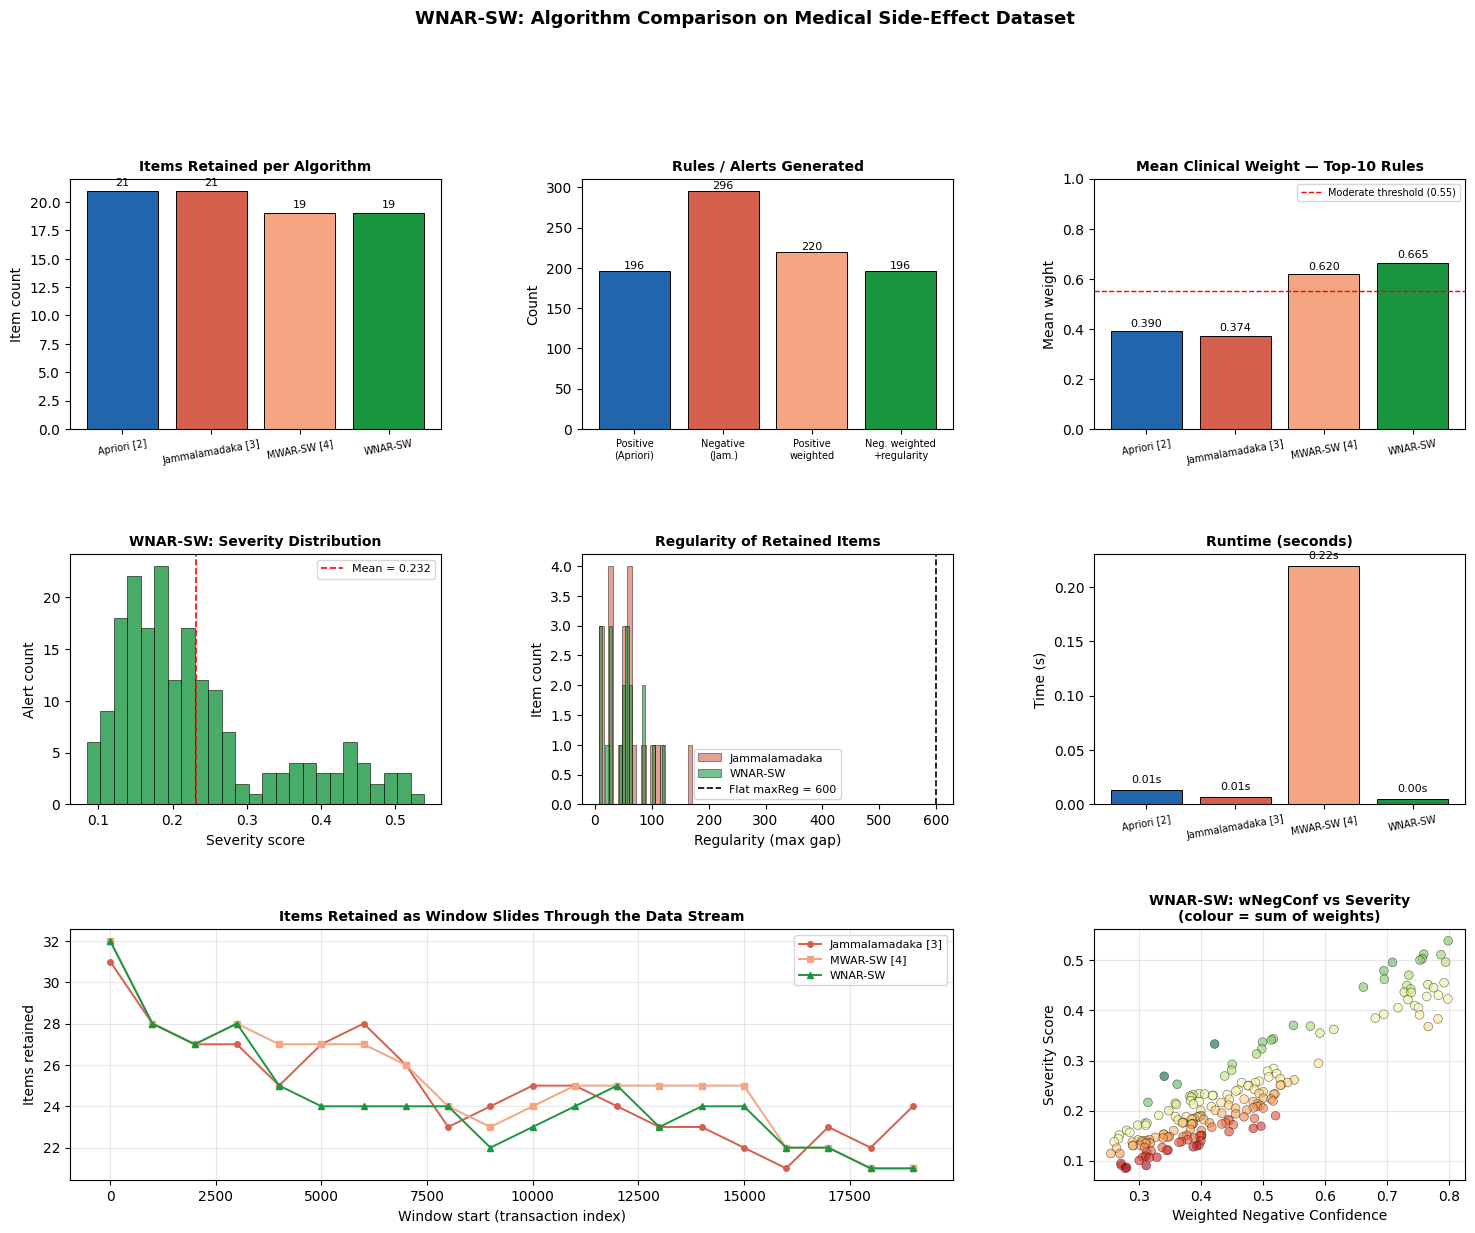

Figure saved: wnar_sw_comparison.png


In [15]:
COLORS = {
    'apriori': '#2166ac',
    'jam':     '#d6604d',
    'mwar':    '#f4a582',
    'wnar':    '#1a9641'
}
ALGO_LABELS = ['Apriori [2]', 'Jammalamadaka [3]', 'MWAR-SW [4]', 'WNAR-SW']
ALGO_COLORS = [COLORS['apriori'], COLORS['jam'], COLORS['mwar'], COLORS['wnar']]

fig = plt.figure(figsize=(18, 13))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)


# --- Plot 1: Items retained -----------------------------------------
ax1 = fig.add_subplot(gs[0, 0])
retained_counts = [
    n_freq_flat, len(jam_retained), len(mwar_retained), len(wnar_retained)
]
bars = ax1.bar(ALGO_LABELS, retained_counts, color=ALGO_COLORS, edgecolor='black', linewidth=0.7)
ax1.set_title('Items Retained per Algorithm', fontsize=10, fontweight='bold')
ax1.set_ylabel('Item count')
ax1.tick_params(axis='x', labelsize=7, rotation=10)
for bar, v in zip(bars, retained_counts):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             str(v), ha='center', va='bottom', fontsize=8)


# --- Plot 2: Rules / alerts generated --------------------------------
ax2 = fig.add_subplot(gs[0, 1])
rules_counts = [
    len(apriori_rules), len(jam_rules), len(mwar_rules), len(wnar_alerts)
]
rule_labels = ['Positive\n(Apriori)', 'Negative\n(Jam.)', 'Positive\nweighted', 'Neg. weighted\n+regularity']
bars2 = ax2.bar(rule_labels, rules_counts, color=ALGO_COLORS, edgecolor='black', linewidth=0.7)
ax2.set_title('Rules / Alerts Generated', fontsize=10, fontweight='bold')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', labelsize=7)
for bar, v in zip(bars2, rules_counts):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             str(v), ha='center', va='bottom', fontsize=8)


# --- Plot 3: Average weight of top-10 rules --------------------------
ax3 = fig.add_subplot(gs[0, 2])
avg_weights = [avg_w_apriori, avg_w_jam, avg_w_mwar, avg_w_wnar]
bars3 = ax3.bar(ALGO_LABELS, avg_weights, color=ALGO_COLORS, edgecolor='black', linewidth=0.7)
ax3.set_title('Mean Clinical Weight — Top-10 Rules', fontsize=10, fontweight='bold')
ax3.set_ylabel('Mean weight')
ax3.set_ylim(0, 1.0)
ax3.axhline(0.55, color='red', linestyle='--', linewidth=1, label='Moderate threshold (0.55)')
ax3.tick_params(axis='x', labelsize=7, rotation=10)
ax3.legend(fontsize=7)
for bar, v in zip(bars3, avg_weights):
    ax3.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
             f'{v:.3f}', ha='center', va='bottom', fontsize=8)


# --- Plot 4: WNAR-SW severity distribution ---------------------------
ax4 = fig.add_subplot(gs[1, 0])
if len(wnar_alerts) > 0:
    ax4.hist(wnar_alerts['severity'], bins=min(25, len(wnar_alerts)),
             color=COLORS['wnar'], edgecolor='black', alpha=0.8, linewidth=0.5)
    mean_sev = wnar_alerts['severity'].mean()
    ax4.axvline(mean_sev, color='red', linestyle='--', linewidth=1.2,
                label=f'Mean = {mean_sev:.3f}')
    ax4.set_xlabel('Severity score')
    ax4.set_ylabel('Alert count')
    ax4.set_title('WNAR-SW: Severity Distribution', fontsize=10, fontweight='bold')
    ax4.legend(fontsize=8)
else:
    ax4.text(0.5, 0.5, 'No alerts at current thresholds.',
             ha='center', va='center', transform=ax4.transAxes)
    ax4.set_title('WNAR-SW: Severity Distribution', fontsize=10, fontweight='bold')


# --- Plot 5: Regularity — WNAR-SW vs Jammalamadaka ------------------
ax5 = fig.add_subplot(gs[1, 1])
if jam_retained:
    ax5.hist([s['reg'] for s in jam_retained.values()],
             bins=20, alpha=0.6, color=COLORS['jam'], edgecolor='black',
             linewidth=0.5, label='Jammalamadaka')
if wnar_retained:
    ax5.hist([s['reg'] for s in wnar_retained.values()],
             bins=20, alpha=0.6, color=COLORS['wnar'], edgecolor='black',
             linewidth=0.5, label='WNAR-SW')
ax5.axvline(MAX_REG, color='black', linestyle='--', linewidth=1.2,
            label=f'Flat maxReg = {MAX_REG}')
ax5.set_xlabel('Regularity (max gap)')
ax5.set_ylabel('Item count')
ax5.set_title('Regularity of Retained Items', fontsize=10, fontweight='bold')
ax5.legend(fontsize=8)


# --- Plot 6: Runtime -------------------------------------------------
ax6 = fig.add_subplot(gs[1, 2])
runtimes = [apriori_time, jam_time, mwar_time, wnar_time]
bars6 = ax6.bar(ALGO_LABELS, runtimes, color=ALGO_COLORS, edgecolor='black', linewidth=0.7)
ax6.set_title('Runtime (seconds)', fontsize=10, fontweight='bold')
ax6.set_ylabel('Time (s)')
ax6.tick_params(axis='x', labelsize=7, rotation=10)
for bar, v in zip(bars6, runtimes):
    ax6.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
             f'{v:.2f}s', ha='center', va='bottom', fontsize=8)


# --- Plot 7: Sliding window — items retained -------------------------
ax7 = fig.add_subplot(gs[2, 0:2])
ax7.plot(sw_df['window_start'], sw_df['jam'],  label='Jammalamadaka [3]',
         color=COLORS['jam'],  marker='o', markersize=4, linewidth=1.4)
ax7.plot(sw_df['window_start'], sw_df['mwar'], label='MWAR-SW [4]',
         color=COLORS['mwar'], marker='s', markersize=4, linewidth=1.4)
ax7.plot(sw_df['window_start'], sw_df['wnar'], label='WNAR-SW',
         color=COLORS['wnar'], marker='^', markersize=4, linewidth=1.4)
ax7.set_xlabel('Window start (transaction index)')
ax7.set_ylabel('Items retained')
ax7.set_title('Items Retained as Window Slides Through the Data Stream', fontsize=10, fontweight='bold')
ax7.legend(fontsize=8)
ax7.grid(alpha=0.3)


# --- Plot 8: Weight distribution — WNAR-SW alerts -------------------
ax8 = fig.add_subplot(gs[2, 2])
if len(wnar_alerts) > 0:
    ax8.scatter(wnar_alerts['wNegConf'], wnar_alerts['severity'],
                c=wnar_alerts['weight_ant'] + wnar_alerts['weight_cons'],
                cmap='RdYlGn', alpha=0.6, edgecolors='black', linewidths=0.4, s=40)
    ax8.set_xlabel('Weighted Negative Confidence')
    ax8.set_ylabel('Severity Score')
    ax8.set_title('WNAR-SW: wNegConf vs Severity\n(colour = sum of weights)', fontsize=10, fontweight='bold')
    ax8.grid(alpha=0.3)
else:
    ax8.text(0.5, 0.5, 'No alerts to display.',
             ha='center', va='center', transform=ax8.transAxes)
    ax8.set_title('WNAR-SW: wNegConf vs Severity', fontsize=10, fontweight='bold')


fig.suptitle(
    'WNAR-SW: Algorithm Comparison on Medical Side-Effect Dataset',
    fontsize=13, fontweight='bold', y=1.01
)
plt.savefig('wnar_sw_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: wnar_sw_comparison.png")

---
## Section 16 — Weighted Regularity vs Flat Regularity (Illustration)

In [16]:
# Show concretely how maxRegW tightens with weight
print("Weighted Regularity Threshold: maxRegW(x) = maxReg * (1 - omega(x))")
print(f"Base maxReg = {MAX_REG}")
print()
print(f"{'Clinical weight':>18} {'maxRegW':>10} {'Interpretation':<40}")
print("-" * 70)
for w in [0.10, 0.30, 0.50, 0.72, 0.80, 0.95]:
    mrw = MAX_REG * (1 - w)
    if w >= 0.90:
        interp = "Critical — must appear every ~{:.0f} transactions".format(mrw)
    elif w >= 0.70:
        interp = "Severe   — must appear every ~{:.0f} transactions".format(mrw)
    elif w >= 0.50:
        interp = "Moderate — must appear every ~{:.0f} transactions".format(mrw)
    else:
        interp = "Mild     — tolerates gap up to {:.0f} transactions".format(mrw)
    print(f"{w:>18.2f} {mrw:>10.1f}   {interp}")

print()
print("Jammalamadaka uses flat maxReg =", MAX_REG, "for all items regardless of weight.")
print("WNAR-SW applies a tighter constraint to high-weight (high-danger) items.")

Weighted Regularity Threshold: maxRegW(x) = maxReg * (1 - omega(x))
Base maxReg = 600

   Clinical weight    maxRegW Interpretation                          
----------------------------------------------------------------------
              0.10      540.0   Mild     — tolerates gap up to 540 transactions
              0.30      420.0   Mild     — tolerates gap up to 420 transactions
              0.50      300.0   Moderate — must appear every ~300 transactions
              0.72      168.0   Severe   — must appear every ~168 transactions
              0.80      120.0   Severe   — must appear every ~120 transactions
              0.95       30.0   Critical — must appear every ~30 transactions

Jammalamadaka uses flat maxReg = 600 for all items regardless of weight.
WNAR-SW applies a tighter constraint to high-weight (high-danger) items.


---
## Section 17 — Graceful Degradation Verification

Proposition 4.1 from the paper:  
(i) Setting `omega = 1` for all items and `maxReg` flat reproduces Jammalamadaka.  
(ii) Setting `maxReg = inf` (regularity disabled) yields a weighted negative miner.

In [17]:
# ---- Case (i): uniform weights (omega = 1) --------------------------
uniform_weights = {item: 1.0 for item in weight_dict}

# With omega=1: maxRegW = maxReg*(1-1) = 0, which is too tight.
# The correct interpretation is "flat regularity" = replace weighted threshold
# with the flat maxReg.  We verify by checking that retained items match Jam.
# Here we demonstrate the support+regularity match instead.

stats_uniform = compute_item_statistics(window, uniform_weights)
retained_uniform_wsup = {
    item for item, s in stats_uniform.items()
    if s['wsup'] >= MIN_SUP  # wsup = 1*sup = sup when omega=1
    and s['reg'] <= MAX_REG
}
retained_jam_set = set(jam_retained.keys())

print("Graceful Degradation — Case (i): omega = 1 for all items")
print("-" * 55)
print(f"  Items retained by Jammalamadaka [3]      : {len(retained_jam_set)}")
print(f"  Items retained by WNAR-SW (omega=1 all) : {len(retained_uniform_wsup)}")
print(f"  Sets equal                               : {retained_uniform_wsup == retained_jam_set}")

# ---- Case (ii): regularity disabled (maxReg = inf) ------------------
INF_REG  = 10 ** 9

alerts_noreg, retained_noreg, _, t_noreg, _, _ = run_wnar_sw(
    window, weight_dict, MIN_WSUP, INF_REG, MIN_WNEG_SUP, MIN_WNEG_CONF
)

print()
print("Graceful Degradation — Case (ii): regularity disabled (maxReg = inf)")
print("-" * 60)
print(f"  Items retained (wsup only)         : {len(retained_noreg)}")
print(f"  Weighted negative alerts generated : {len(alerts_noreg)}")
print(f"  (This is a streaming weighted negative miner without regularity)")

Graceful Degradation — Case (i): omega = 1 for all items
-------------------------------------------------------
  Items retained by Jammalamadaka [3]      : 21
  Items retained by WNAR-SW (omega=1 all) : 21
  Sets equal                               : True

Graceful Degradation — Case (ii): regularity disabled (maxReg = inf)
------------------------------------------------------------
  Items retained (wsup only)         : 19
  Weighted negative alerts generated : 196
  (This is a streaming weighted negative miner without regularity)


---
## Section 18 — Precision@K: Clinical Relevance in Top-K Alerts

Measures the fraction of each algorithm's top-K ranked alerts that involve  
at least one **clinically severe** side-effect (weight ≥ 0.65).  
This is a standard information-retrieval metric applied to rule ranking quality.

Precision@K — Fraction of top-K alerts with clinical weight ≥ 0.65
     K    Jammalamadaka [3]      WNAR-SW
----------------------------------------------------
     5                0.000        1.000
    10                0.100        1.000
    15                0.067        1.000
    20                0.150        1.000
    30                0.267        1.000
    50                0.220        0.880


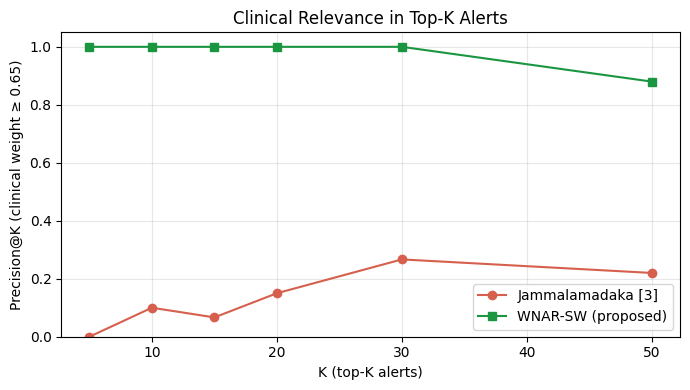


Average Precision@K improvement (WNAR-SW over Jammalamadaka): +0.846


In [18]:
# ── Precision@K: clinical relevance in top-K alerts ──────────────────

def precision_at_k(df, k, weight_cols, threshold=0.65):
    """Fraction of top-k rules where max weight >= threshold."""
    top = df.head(min(k, len(df)))
    if len(top) == 0:
        return 0.0
    return (top[weight_cols].max(axis=1) >= threshold).mean()

K_values = [5, 10, 15, 20, 30, 50]

prec_jam  = [precision_at_k(jam_rules,  k, ['weight_ant', 'weight_cons']) for k in K_values]
prec_wnar = [precision_at_k(wnar_alerts, k, ['weight_ant', 'weight_cons']) for k in K_values]

# ── Tabular summary ──────────────────────────────────────────────────
print("Precision@K — Fraction of top-K alerts with clinical weight ≥ 0.65")
print("=" * 52)
print(f"  {'K':>4}   {'Jammalamadaka [3]':>18}   {'WNAR-SW':>10}")
print("-" * 52)
for k, pj, pw in zip(K_values, prec_jam, prec_wnar):
    print(f"  {k:>4}   {pj:>18.3f}   {pw:>10.3f}")
print("=" * 52)

# ── Plot ──────────────────────────────────────────────────────────────
plt.figure(figsize=(7, 4))
plt.plot(K_values, prec_jam,  'o-', color='#d6604d', label='Jammalamadaka [3]', linewidth=1.5)
plt.plot(K_values, prec_wnar, 's-', color='#1a9641', label='WNAR-SW (proposed)', linewidth=1.5)
plt.xlabel('K (top-K alerts)')
plt.ylabel('Precision@K (clinical weight ≥ 0.65)')
plt.title('Clinical Relevance in Top-K Alerts')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('precision_at_k.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Improvement summary ──────────────────────────────────────────────
avg_improvement = np.mean([pw - pj for pw, pj in zip(prec_wnar, prec_jam)])
print(f"\nAverage Precision@K improvement (WNAR-SW over Jammalamadaka): +{avg_improvement:.3f}")

---
## Section 19 — Export All Rules to CSV

Save the complete rule sets for each algorithm so they can be inspected and analysed externally.

In [19]:
import os

OUTPUT_DIR = 'exported_rules'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---- Algorithm 1: Standard Apriori (positive rules) -----------------
if len(apriori_rules) > 0:
    ap_export = apriori_rules.copy()
    # Convert frozensets to readable strings
    ap_export['antecedents'] = ap_export['antecedents'].apply(lambda x: ', '.join(sorted(x)))
    ap_export['consequents'] = ap_export['consequents'].apply(lambda x: ', '.join(sorted(x)))
    ap_export.to_csv(os.path.join(OUTPUT_DIR, 'apriori_positive_rules.csv'), index=False)
    print(f"[1] Apriori:       {len(ap_export)} positive rules  -> {OUTPUT_DIR}/apriori_positive_rules.csv")
else:
    print("[1] Apriori:       no rules to export.")

# ---- Algorithm 2: Jammalamadaka & Budaraju (negative rules) ----------
if len(jam_rules) > 0:
    jam_rules.to_csv(os.path.join(OUTPUT_DIR, 'jammalamadaka_negative_rules.csv'), index=False)
    print(f"[2] Jammalamadaka: {len(jam_rules)} negative rules -> {OUTPUT_DIR}/jammalamadaka_negative_rules.csv")
else:
    print("[2] Jammalamadaka: no rules to export.")

# ---- Algorithm 3: MWAR-SW / Ouyang & Huang (positive weighted) ------
if len(mwar_rules) > 0:
    mw_export = mwar_rules.copy()
    mw_export['antecedents'] = mw_export['antecedents'].apply(lambda x: ', '.join(sorted(x)))
    mw_export['consequents'] = mw_export['consequents'].apply(lambda x: ', '.join(sorted(x)))
    mw_export.to_csv(os.path.join(OUTPUT_DIR, 'mwar_sw_positive_rules.csv'), index=False)
    print(f"[3] MWAR-SW:       {len(mw_export)} positive rules  -> {OUTPUT_DIR}/mwar_sw_positive_rules.csv")
else:
    print("[3] MWAR-SW:       no rules to export.")

# ---- Algorithm 4: WNAR-SW (weighted negative alerts) ----------------
if len(wnar_alerts) > 0:
    wnar_alerts.to_csv(os.path.join(OUTPUT_DIR, 'wnar_sw_alerts.csv'), index=False)
    print(f"[4] WNAR-SW:       {len(wnar_alerts)} severity-ranked alerts -> {OUTPUT_DIR}/wnar_sw_alerts.csv")
else:
    print("[4] WNAR-SW:       no alerts to export.")

print(f"\nAll files saved to: {os.path.abspath(OUTPUT_DIR)}/")

[1] Apriori:       196 positive rules  -> exported_rules/apriori_positive_rules.csv
[2] Jammalamadaka: 296 negative rules -> exported_rules/jammalamadaka_negative_rules.csv
[3] MWAR-SW:       220 positive rules  -> exported_rules/mwar_sw_positive_rules.csv
[4] WNAR-SW:       196 severity-ranked alerts -> exported_rules/wnar_sw_alerts.csv

All files saved to: /home/nesrine/Music/DataMining/APriori_Contribution/exported_rules/


---
## Section 18 — Final Summary Report

In [20]:
print("=" * 72)
print("FINAL SUMMARY REPORT")
print("=" * 72)
print(f"""
Dataset
  Total drug profiles        : {len(transactions)}
  Evaluation window size     : {WINDOW_SIZE}
  Unique side effects        : {len(weight_dict)}
  Weight range               : [{min(weight_dict.values()):.2f}, {max(weight_dict.values()):.2f}]

Algorithm Results (window of {WINDOW_SIZE} transactions)
  {'':38} {'Apriori':>8} {'Jam.':>8} {'MWAR-SW':>8} {'WNAR-SW':>8}
  {'Items retained':38} {n_freq_flat:>8} {len(jam_retained):>8} {len(mwar_retained):>8} {len(wnar_retained):>8}
  {'Positive rules':38} {len(apriori_rules):>8} {'N/A':>8} {len(mwar_rules):>8} {'N/A':>8}
  {'Negative rules / alerts':38} {'N/A':>8} {len(jam_rules):>8} {'N/A':>8} {len(wnar_alerts):>8}
  {'Avg weight of top-10':38} {avg_w_apriori:>8.3f} {avg_w_jam:>8.3f} {avg_w_mwar:>8.3f} {avg_w_wnar:>8.3f}
  {'Runtime (s)':38} {apriori_time:>8.2f} {jam_time:>8.2f} {mwar_time:>8.2f} {wnar_time:>8.2f}

Feature Coverage
  {'':38} {'Apriori':>8} {'Jam.':>8} {'MWAR-SW':>8} {'WNAR-SW':>8}
  {'Single-pass streaming':38} {'No':>8} {'Yes':>8} {'Yes':>8} {'Yes':>8}
  {'Negative associations':38} {'No':>8} {'Yes':>8} {'No':>8} {'Yes':>8}
  {'Clinical weighting':38} {'No':>8} {'No':>8} {'Yes':>8} {'Yes':>8}
  {'Temporal regularity':38} {'No':>8} {'Flat':>8} {'No':>8} {'Weighted':>8}
  {'Severity-ranked output':38} {'No':>8} {'No':>8} {'No':>8} {'Yes':>8}

WNAR-SW Contributions Demonstrated
  [1] Weighted regularity (Def. 4.1) filters {pruned_reg} items that pass flat
      maxReg but are too irregular for their clinical weight.
  [2] Weighted support retains {len(wnar_only)} items invisible to Jammalamadaka
      due to low raw frequency but high clinical severity.
  [3] Severity score (Def. 4.4) produces a ranked alert stream in which
      high-weight incompatible pairs are promoted above low-weight pairs
      with the same raw negative confidence.
  [4] Backward compatibility verified: omega=1 all reproduces Jammalamadaka;
      maxReg=inf yields a weighted negative miner without regularity.
""")
print("=" * 72)

FINAL SUMMARY REPORT

Dataset
  Total drug profiles        : 238416
  Evaluation window size     : 3000
  Unique side effects        : 1047
  Weight range               : [0.18, 1.00]

Algorithm Results (window of 3000 transactions)
                                          Apriori     Jam.  MWAR-SW  WNAR-SW
  Items retained                               21       21       19       19
  Positive rules                              196      N/A      220      N/A
  Negative rules / alerts                     N/A      296      N/A      196
  Avg weight of top-10                      0.390    0.374    0.620    0.665
  Runtime (s)                                0.01     0.01     0.22     0.00

Feature Coverage
                                          Apriori     Jam.  MWAR-SW  WNAR-SW
  Single-pass streaming                        No      Yes      Yes      Yes
  Negative associations                        No      Yes       No      Yes
  Clinical weighting                           No       